# Simulação Computacional: Quantização e Resolução

Após a amostragem temporal, o sinal discreto ainda possui amplitudes teóricas com infinitas casas decimais. A quantização é o processo de mapear essas amplitudes para um conjunto finito de níveis lógicos definidos pelo número de *bits* ($N$) do sistema.

Neste experimento, aplicaremos conversores analógico-digitais (ADC) teóricos de 3, 4 e 8 bits ao sinal da rede elétrica ($60\,\text{Hz}$, amostrado a $480\,\text{Hz}$). Avaliaremos a resolução ($\Delta V$), a quantidade de níveis ($L$) e o erro de quantização gerado pelo arredondamento.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

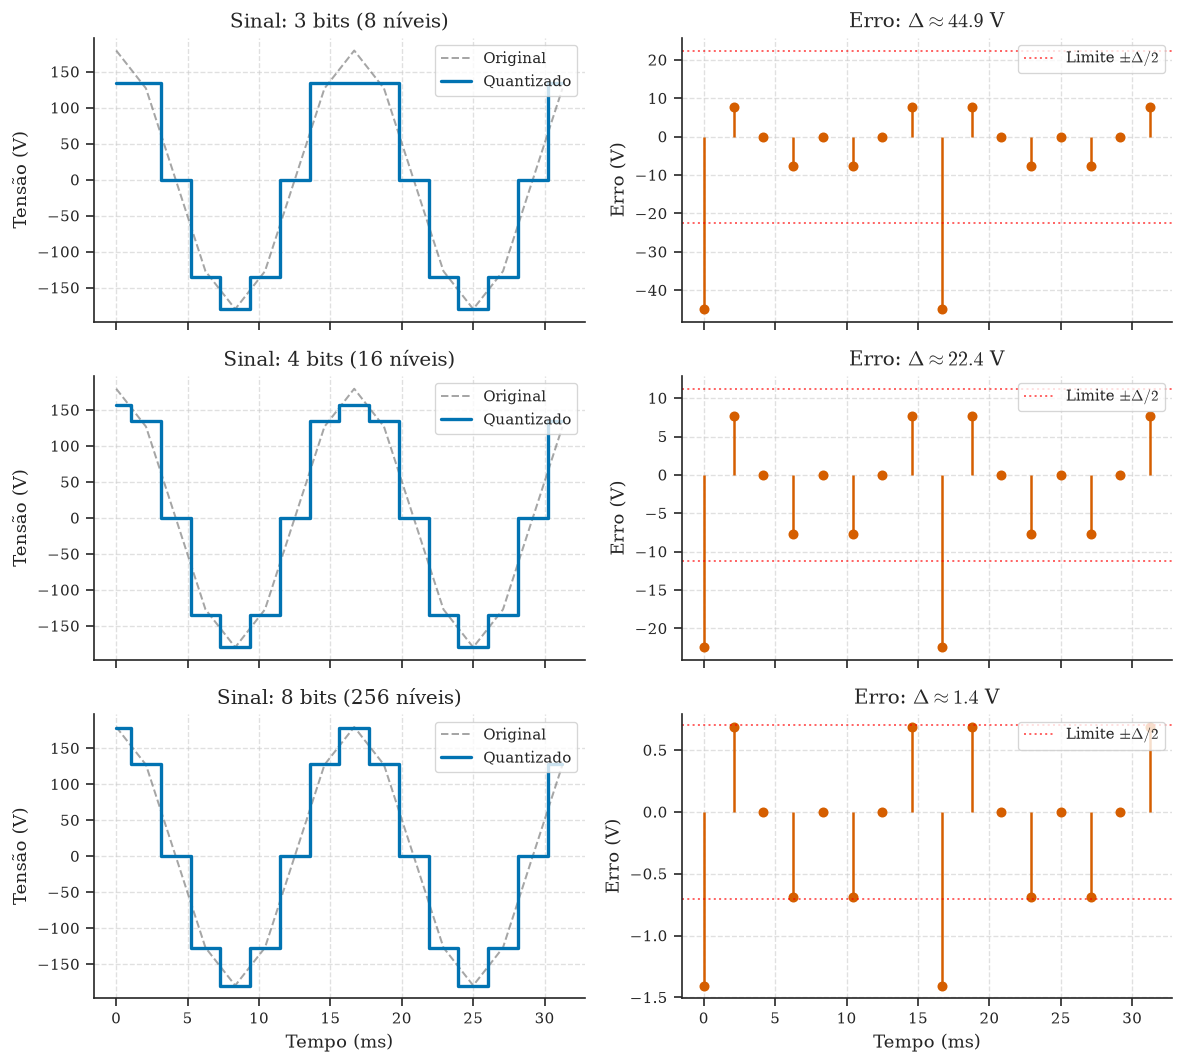

In [2]:
# Parâmetros do sinal base (Amostragem ideal do Tópico 1)
f0 = 60.0
A = 179.6
fs = 480.0
t_end = 2.0 / f0  # 2 ciclos completos (33.33 ms)
t = np.arange(0, t_end, 1/fs)
x = A * np.cos(2 * np.pi * f0 * t)

# Parâmetros do Conversor Analógico-Digital (ADC)
V_ref = 2 * A  # Excursão total pico a pico (-179.6V a +179.6V = 359.2V)
resolucoes_bits = [3, 4, 8]

# Configuração da Figura
fig, axes = plt.subplots(3, 2, figsize=(10, 9), sharex=True)
cores = sns.color_palette("colorblind")

for i, N in enumerate(resolucoes_bits):
    L = 2**N
    delta = V_ref / L  # Resolução (tamanho do degrau)
    
    # Processo de Quantização (Bipolar com arredondamento)
    x_q = np.round(x / delta) * delta
    # Limitador para não ultrapassar a escala máxima
    x_q = np.clip(x_q, -A, A - delta) 
    
    erro = x_q - x
    
    # Coluna Esquerda: Sinal Original vs Quantizado
    ax_sig = axes[i, 0]
    ax_sig.plot(t * 1000, x, color="gray", linestyle="--", alpha=0.7, label="Original")
    ax_sig.step(t * 1000, x_q, where="mid", color=cores[0], linewidth=2, label=f"Quantizado")
    ax_sig.set_title(f"Sinal: {N} bits ({L} níveis)")
    ax_sig.set_ylabel("Tensão (V)")
    ax_sig.legend(loc="upper right", fontsize=9)
    
    # Coluna Direita: Erro de Quantização
    ax_err = axes[i, 1]
    markerline, stemlines, baseline = ax_err.stem(
        t * 1000, erro, linefmt="-", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, color=cores[3], linewidth=1.5)
    plt.setp(markerline, color=cores[3], markersize=5)
    ax_err.axhline(delta/2, color='red', linestyle=':', alpha=0.6, label=r"Limite $\pm \Delta/2$")
    ax_err.axhline(-delta/2, color='red', linestyle=':', alpha=0.6)
    ax_err.set_title(rf"Erro: $\Delta \approx {delta:.1f}$ V")
    ax_err.set_ylabel("Erro (V)")
    ax_err.legend(loc="upper right", fontsize=9)

axes[-1, 0].set_xlabel("Tempo (ms)")
axes[-1, 1].set_xlabel("Tempo (ms)")

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_quantizacao.png")
plt.show()

In [3]:
print("=== RESULTADOS NUMÉRICOS DA QUANTIZAÇÃO ===")
print(f"Excursão de Tensão (V_ref): {V_ref:.2f} V")
print("=" * 45)

for N in resolucoes_bits:
    L = 2**N
    delta = V_ref / L
    x_q = np.round(x / delta) * delta
    x_q = np.clip(x_q, -A, A - delta)
    erro_max = np.max(np.abs(x_q - x))
    
    print(f"Bits (N)         : {N}")
    print(f"Níveis (L)       : {L}")
    print(f"Resolução (Δ)    : {delta:6.2f} V")
    print(f"Erro Máx medido  : {erro_max:6.2f} V (Teórico: {delta/2:.2f} V)")
    print("-" * 45)

=== RESULTADOS NUMÉRICOS DA QUANTIZAÇÃO ===
Excursão de Tensão (V_ref): 359.20 V
Bits (N)         : 3
Níveis (L)       : 8
Resolução (Δ)    :  44.90 V
Erro Máx medido  :  44.90 V (Teórico: 22.45 V)
---------------------------------------------
Bits (N)         : 4
Níveis (L)       : 16
Resolução (Δ)    :  22.45 V
Erro Máx medido  :  22.45 V (Teórico: 11.22 V)
---------------------------------------------
Bits (N)         : 8
Níveis (L)       : 256
Resolução (Δ)    :   1.40 V
Erro Máx medido  :   1.40 V (Teórico: 0.70 V)
---------------------------------------------
